In [1]:
import os
import warnings 
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import mapclassify
import seaborn as sns
import contextily as ctx
from scipy import stats

In [2]:
zonificacion=gpd.read_file(r'carto\areas.gpkg')
estaciones=gpd.read_file(r'carto\estaciones.gpkg')
print(zonificacion.crs)
zonificacion.head()

EPSG:4326


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,cod_ah,nom_ah,cod_zh,nom_zh,cod_szh,nom_szh,geometry
0,6080000510,0,6080000510,6080000510,0.0,0.0,3.8,3.8,61100705,0,1,0,91,1.0,Caribe,12.0,Caribe - Litoral,1205.0,Directos Caribe Golfo de Morrosquillo,"MULTIPOLYGON (((-75.575 9.57083, -75.575 9.6, ..."
1,6080154560,6080157220,6080004470,6080004470,2116.2,2116.2,340.1,45792.9,61597055,0,0,1,2128,3.0,Orinoco,32.0,Guaviare,3210.0,Medio Guaviare,"MULTIPOLYGON (((-71.2 2.8875, -71.2 2.89167, -..."
2,6080000500,0,6080000500,6080000500,0.0,0.0,274.5,274.6,61100704,0,0,1,90,1.0,Caribe,12.0,Caribe - Litoral,1205.0,Directos Caribe Golfo de Morrosquillo,"MULTIPOLYGON (((-75.49583 9.45417, -75.49619 9..."
3,6080167070,6080165760,6080004470,6080004470,2225.5,2225.5,395.0,395.0,61594794,0,0,3,2143,3.0,Orinoco,31.0,Inírida,3101.0,Río Inírida Alto,"MULTIPOLYGON (((-72 2.4375, -72.00743 2.43816,..."
4,6080000490,0,6080000490,6080000490,0.0,0.0,89.9,90.0,61100703,0,1,0,89,1.0,Caribe,12.0,Caribe - Litoral,1205.0,Directos Caribe Golfo de Morrosquillo,"MULTIPOLYGON (((-75.62917 9.4375, -75.62881 9...."


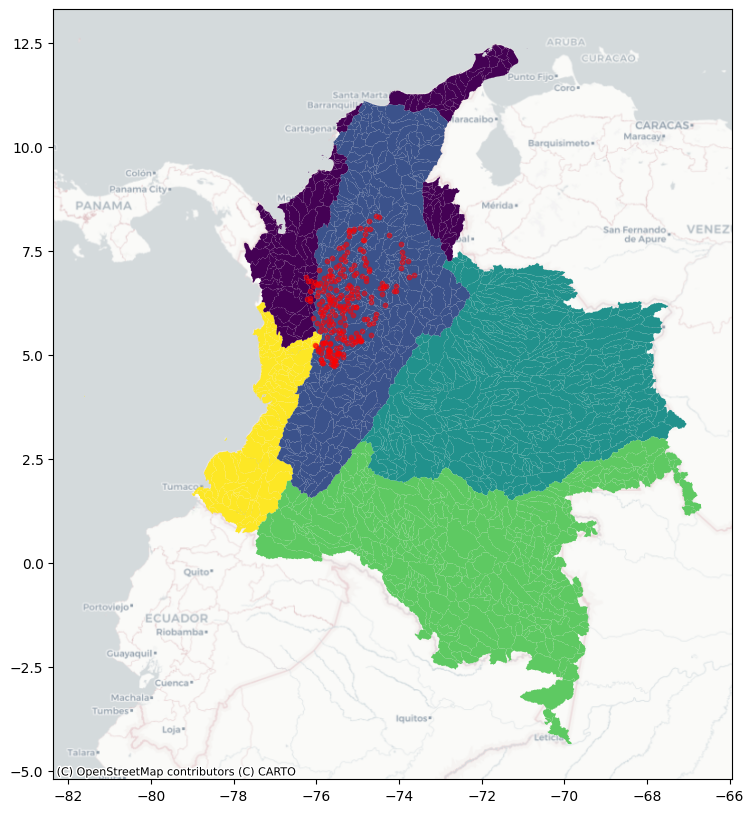

In [3]:
fig,ax=plt.subplots(figsize=(10,10))
zonificacion.plot(ax=ax,column='cod_ah')
estaciones.plot(ax=ax,color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax,crs=zonificacion.crs,source=ctx.providers.CartoDB.Positron)

In [4]:
print(zonificacion['nom_ah'].unique())
borrar=['Orinoco','Amazonas']
areas=zonificacion[~zonificacion['nom_ah'].isin(borrar)].dropna(subset=['nom_ah'])

<StringArray>
['Caribe', 'Orinoco', 'Amazonas', 'Magdalena Cauca', nan, 'Pacifico']
Length: 6, dtype: str


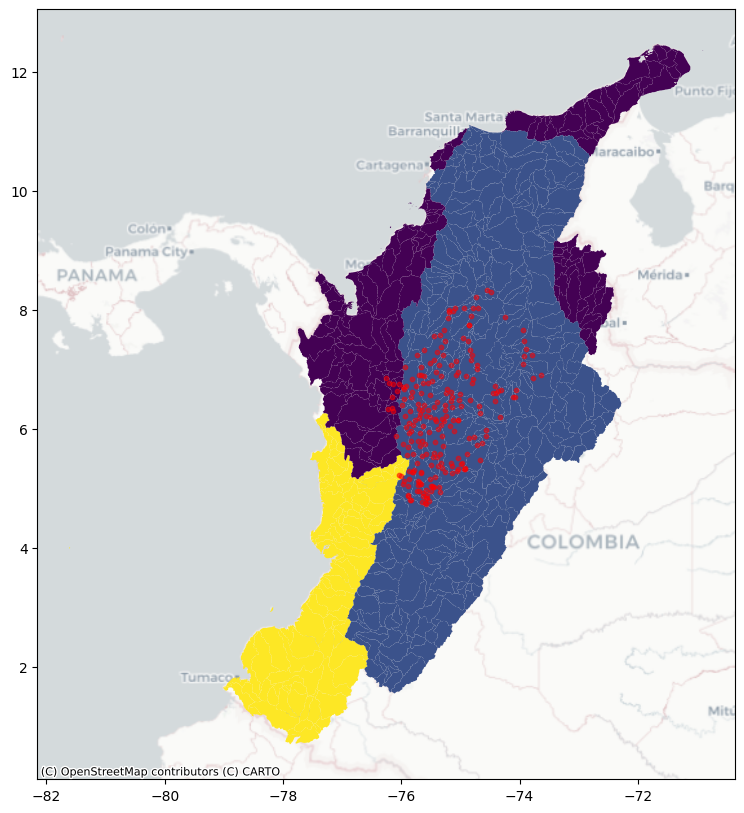

In [5]:
fig,ax=plt.subplots(figsize=(10,10))
areas.plot(ax=ax,column='cod_ah')
estaciones.plot(ax=ax,color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax,crs=areas.crs,source=ctx.providers.CartoDB.Positron)

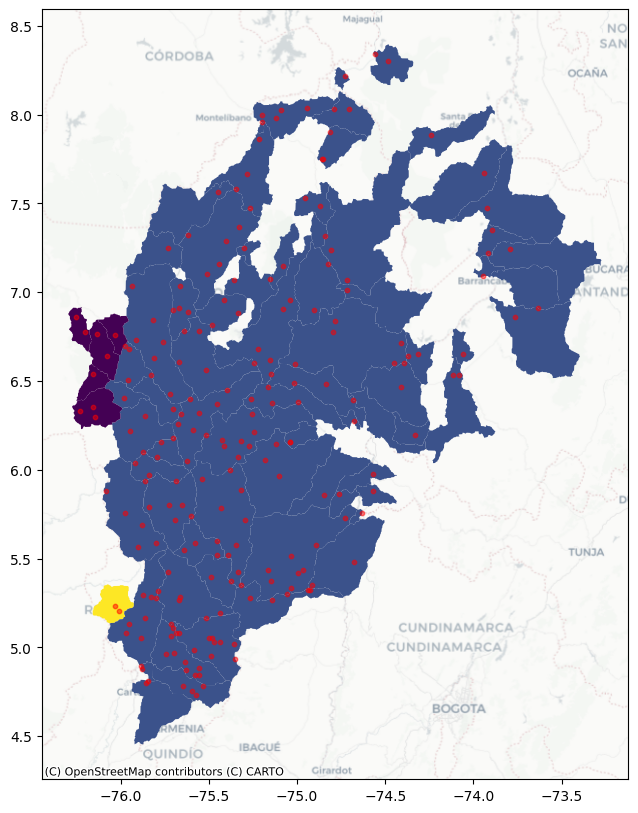

In [6]:
cuencas_con_puntos = areas[areas.geometry.intersects(estaciones.unary_union)]

fig,ax=plt.subplots(figsize=(10,10))
cuencas_con_puntos.plot(ax=ax,column='cod_ah')
estaciones.plot(ax=ax,color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax,crs=cuencas_con_puntos.crs,source=ctx.providers.CartoDB.Positron)

In [7]:
cuencas_con_puntos.to_file(r'carto\areas_limpio.gpkg')

In [8]:
cuencas_con_puntos.head()

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,cod_ah,nom_ah,cod_zh,nom_zh,cod_szh,nom_szh,geometry
561,6080113930,6080113790,6080034060,6080034060,325.1,325.1,408.5,408.5,67208098,0,0,2,21897,5.0,Pacifico,54.0,San Juán,5401.0,Río San Juan Alto,"MULTIPOLYGON (((-76.09583 5.34167, -76.09583 5..."
1031,6080122070,6080120720,6080000740,6080000740,996.8,996.8,863.3,2752.3,61204801,0,0,3,387,2.0,Magdalena Cauca,26.0,Cauca,2612.0,Río La Vieja,"MULTIPOLYGON (((-75.70417 4.7375, -75.64758 4...."
1151,6080092490,6080091040,6080000740,6080000740,663.1,663.1,1636.0,1636.0,61209104,0,0,2,279,2.0,Magdalena Cauca,23.0,Medio Magdalena,2314.0,Río Opón,"MULTIPOLYGON (((-73.73333 6.5625, -73.73407 6...."
1155,6080092580,6080089730,6080000740,6080000740,653.1,653.1,510.7,510.8,61204448,0,0,5,275,2.0,Magdalena Cauca,27.0,Nechí,2702.0,Alto Nechí,"MULTIPOLYGON (((-75.49167 6.80833, -75.49167 6..."
1157,6080091060,6080090450,6080000740,6080000740,651.9,651.9,494.8,494.8,61204572,0,0,3,273,2.0,Magdalena Cauca,26.0,Cauca,2620.0,Directos río Cauca entre río San Juan y Pto. V...,"MULTIPOLYGON (((-75.69167 7.07917, -75.68835 7..."


In [9]:
cuencas=gpd.read_file(r"carto\CUENCAS_FINAL.gpkg")
print(cuencas.columns)
cuencas.head()

Index(['HYBAS_ID', 'SUB_AREA', 'cod_ah', 'nom_ah', 'cod_zh', 'nom_zh',
       'cod_szh', 'nom_szh', 'PMA_cuenca', 'altura_mean', 'area[km2]',
       'Beta_media', 'Beta_std', 'P24_media', 'P24_std', 'index_extremal',
       'FRA', 'geometry'],
      dtype='str')


,HYBAS_ID,SUB_AREA,cod_ah,nom_ah,cod_zh,nom_zh,cod_szh,nom_szh,PMA_cuenca,altura_mean,area[km2],Beta_media,Beta_std,P24_media,P24_std,index_extremal,FRA,geometry
0,6080113930,408.5,5.0,Pacifico,54.0,San Juán,5401.0,Río San Juan Alto,2353.847,1796.958813,406.735429,-0.524,0.148,70.009,18.429,0.029742,0.89,"MULTIPOLYGON (((-76.09583 5.34167, -76.09583 5..."
1,6080092490,1636.0,2.0,Magdalena Cauca,23.0,Medio Magdalena,2314.0,Río Opón,2557.302,523.405974,1628.953560,-0.628,0.147,117.292,27.340,0.045866,0.77,"MULTIPOLYGON (((-73.73333 6.5625, -73.73407 6...."
2,6080092580,510.7,2.0,Magdalena Cauca,27.0,Nechí,2702.0,Alto Nechí,2822.177,2291.360728,508.551526,-0.520,0.078,81.481,12.463,0.028872,0.71,"MULTIPOLYGON (((-75.49167 6.80833, -75.49167 6..."
3,6080091060,494.8,2.0,Magdalena Cauca,26.0,Cauca,2620.0,Directos río Cauca entre río San Juan y Pto. V...,2117.810,2182.354180,492.656786,-0.530,0.060,64.095,7.078,0.030265,0.56,"MULTIPOLYGON (((-75.69167 7.07917, -75.68835 7..."
4,6080091020,2013.9,2.0,Magdalena Cauca,26.0,Cauca,2620.0,Directos río Cauca entre río San Juan y Pto. V...,1883.559,1580.152260,2005.268450,-0.585,0.031,65.781,3.687,0.034924,0.52,"MULTIPOLYGON (((-75.95417 6.8375, -75.95452 6...."


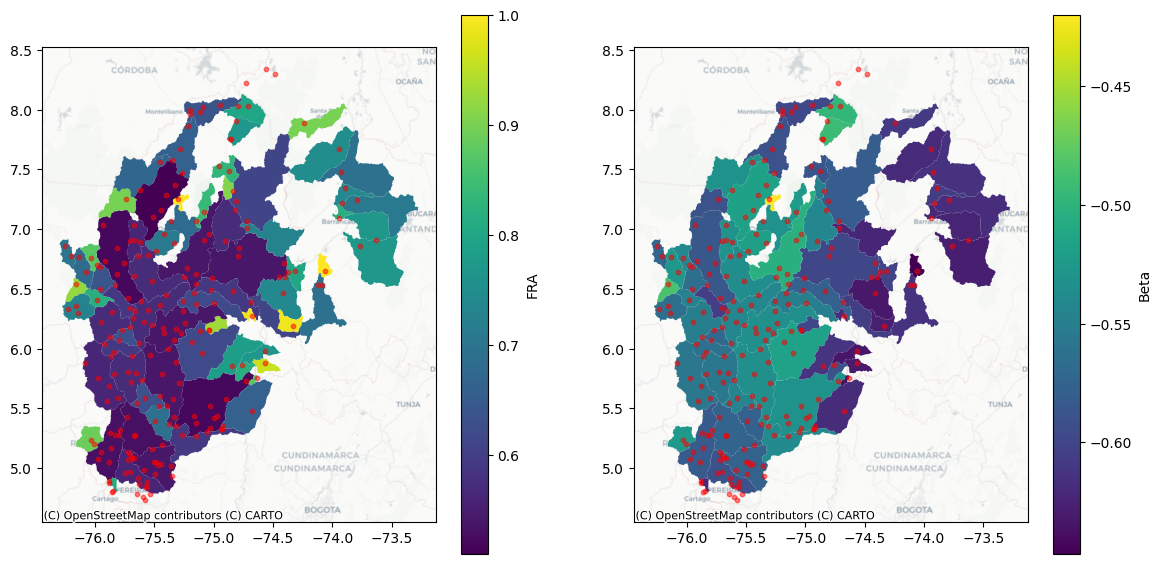

In [10]:
fig,ax=plt.subplots(1,2,figsize=(14,7))
cuencas.plot(ax=ax[0],column='FRA',legend=True,legend_kwds={'label': 'FRA','orientation':'vertical'})
estaciones.plot(ax=ax[0],color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax[0],crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)

cuencas.plot(ax=ax[1],column='Beta_media',legend=True,legend_kwds={'label': 'Beta','orientation':'vertical'})
estaciones.plot(ax=ax[1],color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax[1],crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)


In [11]:
cuencas['FRA'].describe()

count    72.000000
mean      0.707783
std       0.140708
min       0.510000
25%       0.585000
50%       0.690000
75%       0.812500
max       1.000000
Name: FRA, dtype: float64

### Dado que FRA es continua, no se buscan distribuciones de conteo
Se ajustan distribuciones Logit y normal para ver cual es la que mejor se ajusta y se observan correlaciones entre las variables predictoras y FRA

In [12]:
# -------------------- #
# variable dependiente #
# -------------------- #

var_y='FRA'

# -------------------- #
# Variables predictoras #
# -------------------- #

predictoras=['PMA_cuenca', 'altura_mean', 'area[km2]','Beta_media', 'Beta_std', 'P24_media', 'P24_std', 'index_extremal']

cols=[var_y]+predictoras
df = cuencas[cols].copy()
df = df.dropna(subset=[var_y])

# FRA debe estar entre 0 y 1
df = df[(df[var_y] >= 0) & (df[var_y] <= 1)].copy()

y = df[var_y].values

# ==========================
# Ajuste Normal
# ==========================

mu_norm, sigma_norm = stats.norm.fit(y)

# ==========================
# Ajuste Log normal
# ==========================

params = stats.lognorm.fit(y)

# ==========================
# Ajuste Logit-normal
# ==========================
y_logit = y[(y > 0) & (y < 1)]
eps = 1e-6

z = np.log(y_logit / (1 - y_logit))

mu_logit, sigma_logit = stats.norm.fit(z)

def pdf_logitnormal(x, mu, sigma):
    x = np.clip(x, eps, 1 - eps)
    z = np.log(x / (1 - x))
    return stats.norm.pdf(z, mu, sigma) / (x * (1 - x))

def ppf_logitnormal(p, mu, sigma):
    zq = stats.norm.ppf(p, loc=mu, scale=sigma)
    return 1 / (1 + np.exp(-zq))

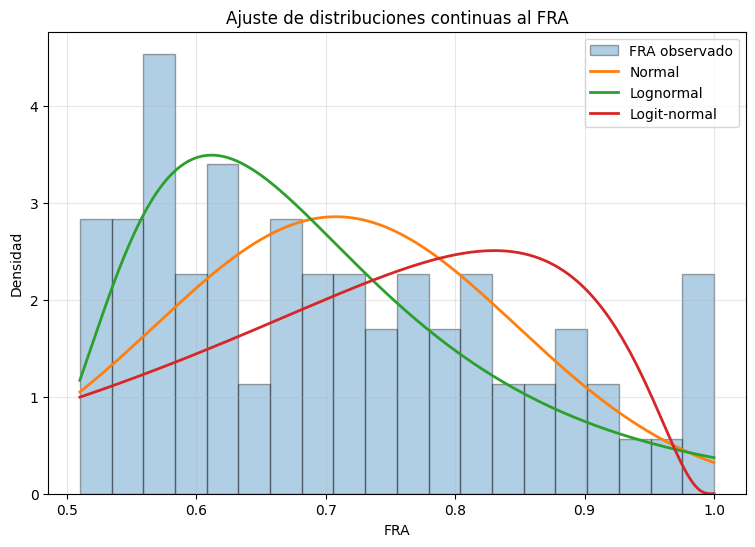

In [13]:
# Gráficas 
x = np.linspace(y.min(), y.max(), 500)

pdf_norm = stats.norm.pdf(x, mu_norm, sigma_norm)

pdf_lognorm = stats.lognorm.pdf(
    x,
    *params
)
x_logit=np.linspace(y_logit.min(), y_logit.max(), 500)

pdf_logit = pdf_logitnormal(
    x,
    mu_logit,
    sigma_logit
)


plt.figure(figsize=(9, 6))

plt.hist(
    y,
    bins=20,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="FRA observado"
)

plt.plot(x, pdf_norm, linewidth=2, label="Normal")
plt.plot(x, pdf_lognorm, linewidth=2, label="Lognormal")
plt.plot(x, pdf_logit, linewidth=2, label="Logit-normal")

plt.xlabel("FRA")
plt.ylabel("Densidad")
plt.title("Ajuste de distribuciones continuas al FRA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Comparar cual es el mejor ajuste con AIC y BIC
n = len(y)

# ==========================
# Log-verosimilitudes
# ==========================

ll_norm = np.sum(stats.norm.logpdf(y, mu_norm, sigma_norm))

ll_lognorm = np.sum(stats.lognorm.logpdf(
    y,
    *params
))

ll_logit = np.sum(np.log(
    pdf_logitnormal(y, mu_logit, sigma_logit)
))


# ==========================
# Número de parámetros
# ==========================

k_norm = 2
k_lognorm = 2
k_logit = 2

# ==========================
# Tabla resumen
# ==========================

ajustes = pd.DataFrame({
    "Distribucion": [
        "Normal",
        "Log-normal",
        "Logit-normal"
    ],
    "LogLik": [
        ll_norm,
        ll_lognorm,
        ll_logit
    ],
    "k": [
        k_norm,
        k_lognorm,
        k_logit
    ]
})

ajustes["AIC"] = 2 * ajustes["k"] - 2 * ajustes["LogLik"]
ajustes["BIC"] = ajustes["k"] * np.log(n) - 2 * ajustes["LogLik"]

ajustes = ajustes.sort_values("AIC")

print(ajustes)

   Distribucion      LogLik  k         AIC         BIC
1    Log-normal   43.852891  2  -83.705782  -79.152450
0        Normal   39.536699  2  -75.073399  -70.520067
2  Logit-normal -133.258856  2  270.517712  275.071045


### Correlación de variables predictoras

In [15]:
resultados_pearson = []

for var in predictoras:
    temp = df[[var_y, var]].dropna()

    if len(temp) > 2:
        r, p = stats.pearsonr(temp[var], temp[var_y])

        resultados_pearson.append({
            "Variable": var,
            "Pearson_r": r,
            "p_value": float(p),
            "n": len(temp),
            "r_abs": abs(r)
        })

corr_pearson = pd.DataFrame(resultados_pearson)

corr_pearson = corr_pearson.sort_values(
    by="r_abs",
    ascending=False
).drop(columns="r_abs")

print(corr_pearson)

         Variable  Pearson_r       p_value   n
4        Beta_std   0.823953  6.188279e-19  72
6         P24_std   0.783307  4.242892e-16  72
2       area[km2]  -0.655187  4.254606e-10  72
1     altura_mean  -0.396441  5.658855e-04  72
5       P24_media   0.335562  3.957159e-03  72
7  index_extremal   0.276134  1.887893e-02  72
3      Beta_media  -0.191963  1.062209e-01  72
0      PMA_cuenca   0.138617  2.455458e-01  72


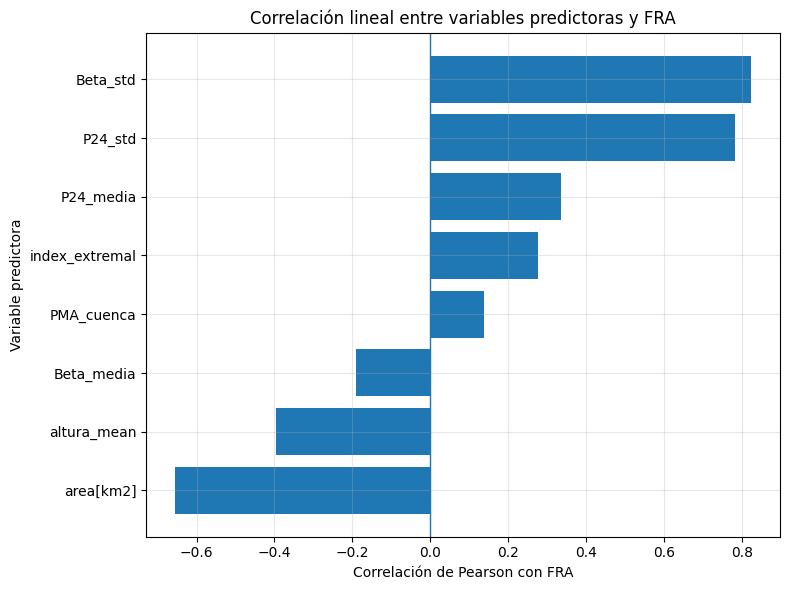

In [16]:
corr_plot = corr_pearson.sort_values("Pearson_r").copy()

plt.figure(figsize=(8, 6))

plt.barh(
    corr_plot["Variable"],
    corr_plot["Pearson_r"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Correlación de Pearson con FRA")
plt.ylabel("Variable predictora")
plt.title("Correlación lineal entre variables predictoras y FRA")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

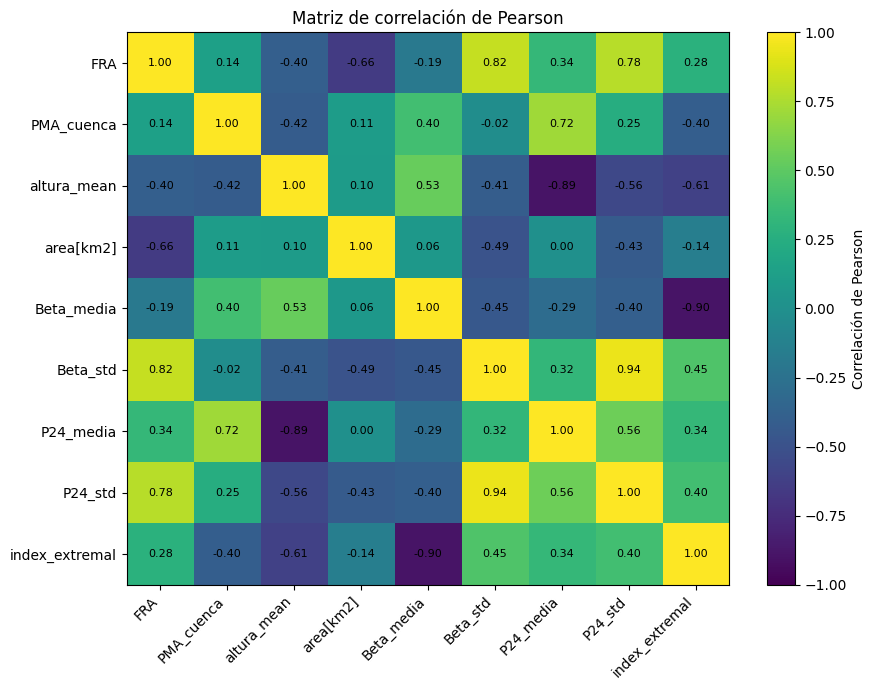

In [17]:
df_corr = df[[var_y] + predictoras].dropna().copy()

matriz_pearson = df_corr.corr(method="pearson")

plt.figure(figsize=(9, 7))

plt.imshow(
    matriz_pearson,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlación de Pearson")

plt.xticks(
    ticks=np.arange(len(matriz_pearson.columns)),
    labels=matriz_pearson.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(matriz_pearson.index)),
    labels=matriz_pearson.index
)

for i in range(len(matriz_pearson.index)):
    for j in range(len(matriz_pearson.columns)):
        valor = matriz_pearson.iloc[i, j]
        plt.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

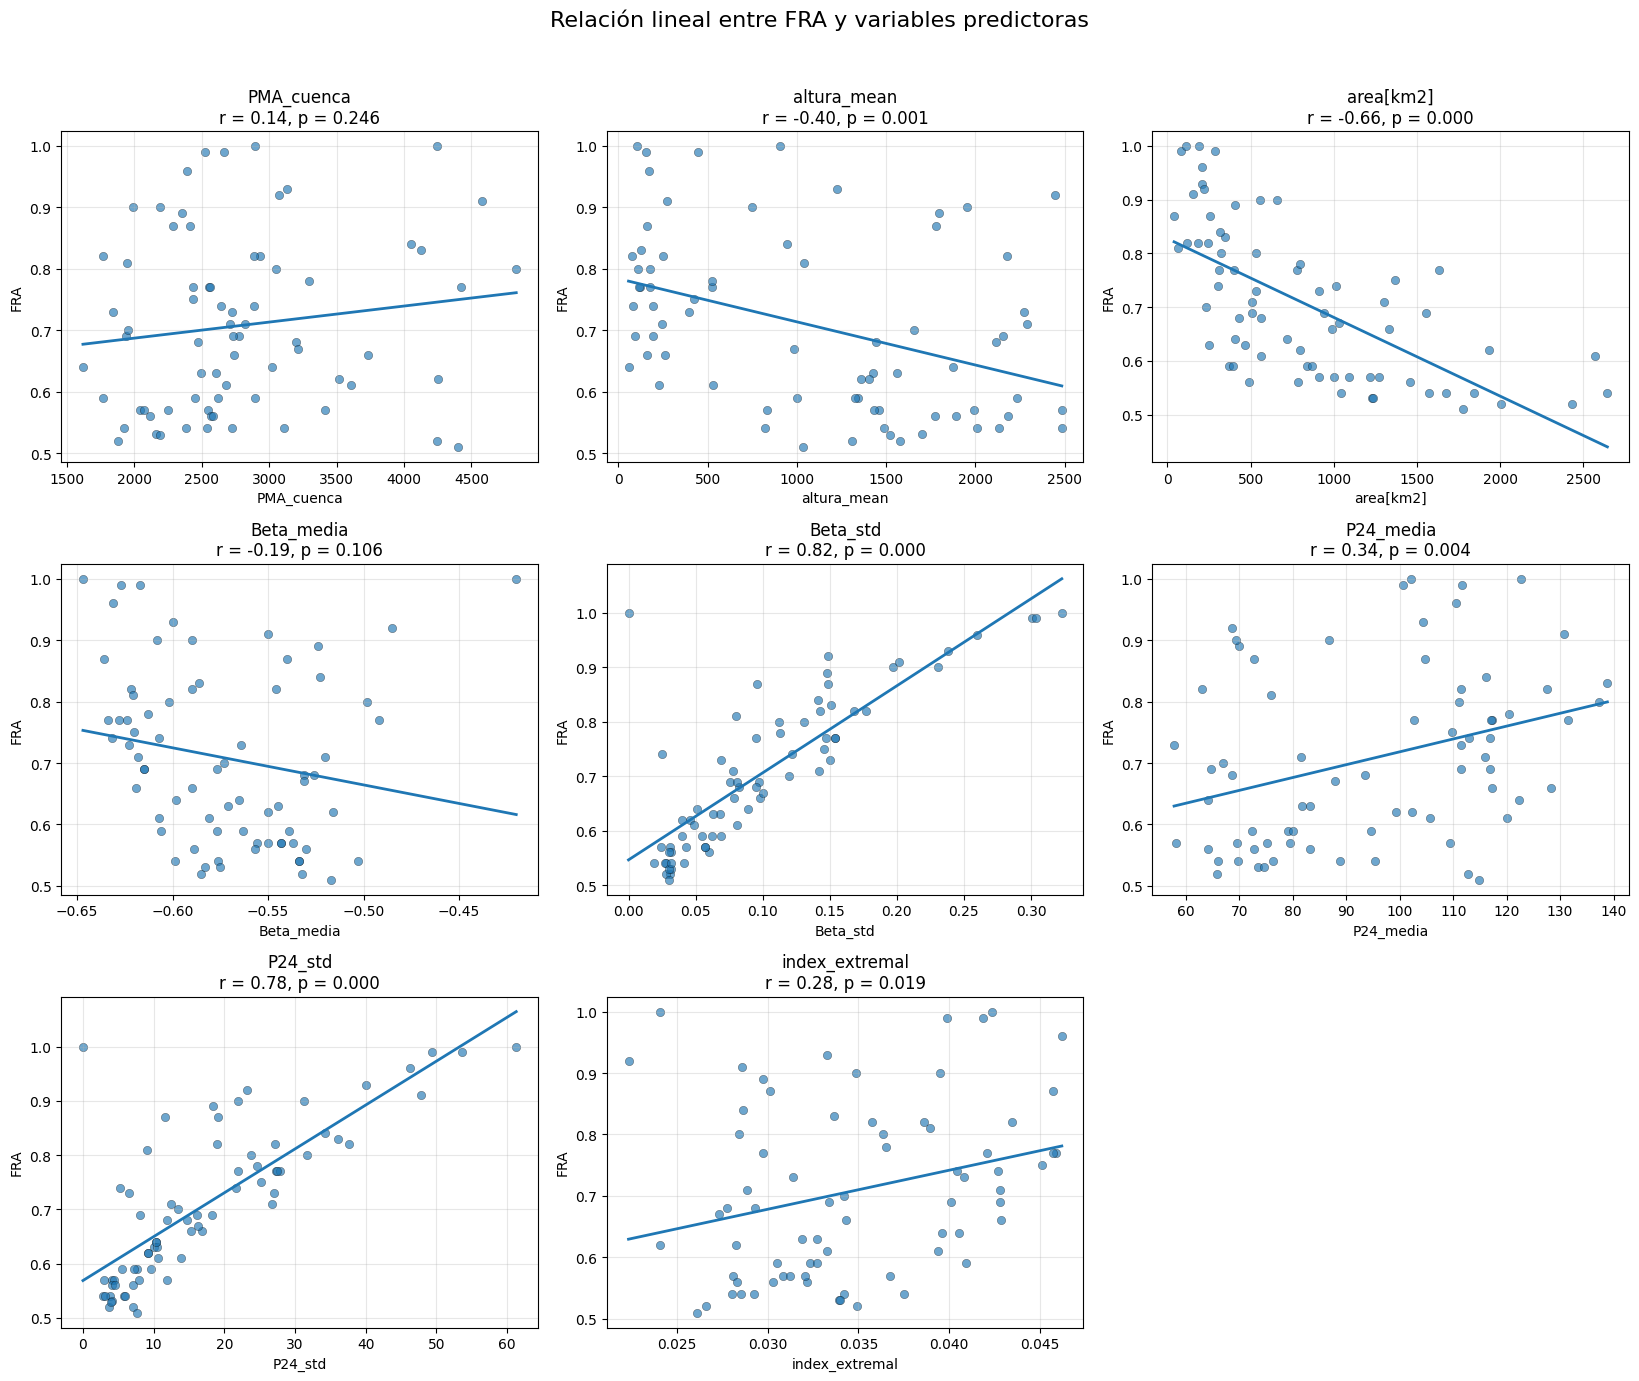

In [18]:
n_vars = len(predictoras)

n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_rows)
)

axes = axes.flatten()

for i, var in enumerate(predictoras):

    ax = axes[i]

    temp = df[[var_y, var]].dropna()

    if len(temp) <= 2:
        ax.axis("off")
        continue

    x = temp[var].values
    y = temp[var_y].values

    r, p = stats.pearsonr(x, y)

    m, b = np.polyfit(x, y, 1)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b

    ax.scatter(
        x,
        y,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.3
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2
    )

    ax.set_xlabel(var)
    ax.set_ylabel("FRA")
    ax.set_title(f"{var}\nr = {r:.2f}, p = {p:.3f}")
    ax.grid(alpha=0.3)

# Apagar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Relación lineal entre FRA y variables predictoras",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### GML Gaussiano
Se corrigen los datos con logaritmo, la mejor distribución es lognormal, pero igual se usa un modelo normal

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Opcional si tienes Cambria instalada
plt.rcParams["font.family"] = "Cambria"

# -------------------- #
# Variable respuesta
# -------------------- #

var_y = "FRA"

# -------------------- #
# Variables predictoras
# -------------------- #

predictoras = [
    "PMA_cuenca",
    "altura_mean",
    "area[km2]",
    "Beta_media",
    "Beta_std",
    "P24_media",
    "P24_std",
    "index_extremal"
]

cols = [var_y] + predictoras

df_model = cuencas[cols].copy()

# Convertir a numérico
for c in cols:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

# Eliminar infinitos y nulos
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=cols).copy()

# -------------------- #
# Matriz X y vector y
# -------------------- #

X_raw = df_model[predictoras].copy()
y = df_model[var_y].copy()

# Escalar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convertir a DataFrame para conservar nombres
X_scaled = pd.DataFrame(
    X_scaled,
    columns=predictoras,
    index=df_model.index
)

# Agregar constante/intercepto
X = sm.add_constant(X_scaled)

# -------------------- #
# Modelo GLM Gaussiano
# -------------------- #

modelo_glm = sm.GLM(
    y,
    X,
    family=sm.families.Gaussian()
)

resultado_glm = modelo_glm.fit()

print(resultado_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    FRA   No. Observations:                   72
Model:                            GLM   Df Residuals:                       63
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                       0.0035494
Method:                          IRLS   Log-Likelihood:                 105.72
Date:                Tue, 14 Jul 2026   Deviance:                      0.22361
Time:                        00:55:40   Pearson chi2:                    0.224
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9903
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.7078      0.007    100.

In [20]:
# Predicciones
df_model["FRA_pred"] = resultado_glm.predict(X)

# Residuos
df_model["residuo"] = df_model["FRA"] - df_model["FRA_pred"]

# Residuo absoluto
df_model["residuo_abs"] = df_model["residuo"].abs()

# Copiar resultados a la capa original
cuencas["FRA_pred"] = np.nan
cuencas["residuo"] = np.nan
cuencas["residuo_abs"] = np.nan

cuencas.loc[df_model.index, "FRA_pred"] = df_model["FRA_pred"]
cuencas.loc[df_model.index, "residuo"] = df_model["residuo"]
cuencas.loc[df_model.index, "residuo_abs"] = df_model["residuo_abs"]
rmse = np.sqrt(mean_squared_error(df_model["FRA"], df_model["FRA_pred"]))
mae = mean_absolute_error(df_model["FRA"], df_model["FRA_pred"])
r2 = r2_score(df_model["FRA"], df_model["FRA_pred"])

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)
print("AIC:", resultado_glm.aic)
print("BIC:", resultado_glm.bic)


RMSE: 0.05572878085723794
MAE: 0.04400757479290381
R²: 0.8409280063794164
AIC: -193.4380829253248
BIC: -269.20635531287144


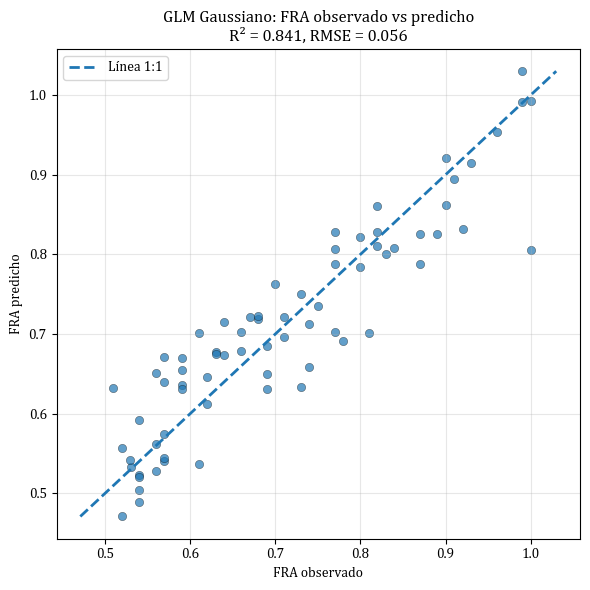

In [21]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df_model["FRA"],
    df_model["FRA_pred"],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

min_val = min(df_model["FRA"].min(), df_model["FRA_pred"].min())
max_val = max(df_model["FRA"].max(), df_model["FRA_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="Línea 1:1"
)

plt.xlabel("FRA observado")
plt.ylabel("FRA predicho")
plt.title(f"GLM Gaussiano: FRA observado vs predicho\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

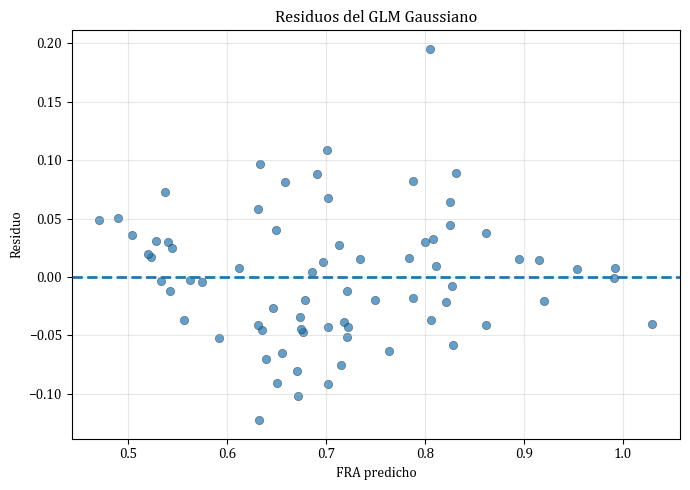

In [22]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_model["FRA_pred"],
    df_model["residuo"],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("FRA predicho")
plt.ylabel("Residuo")
plt.title("Residuos del GLM Gaussiano")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

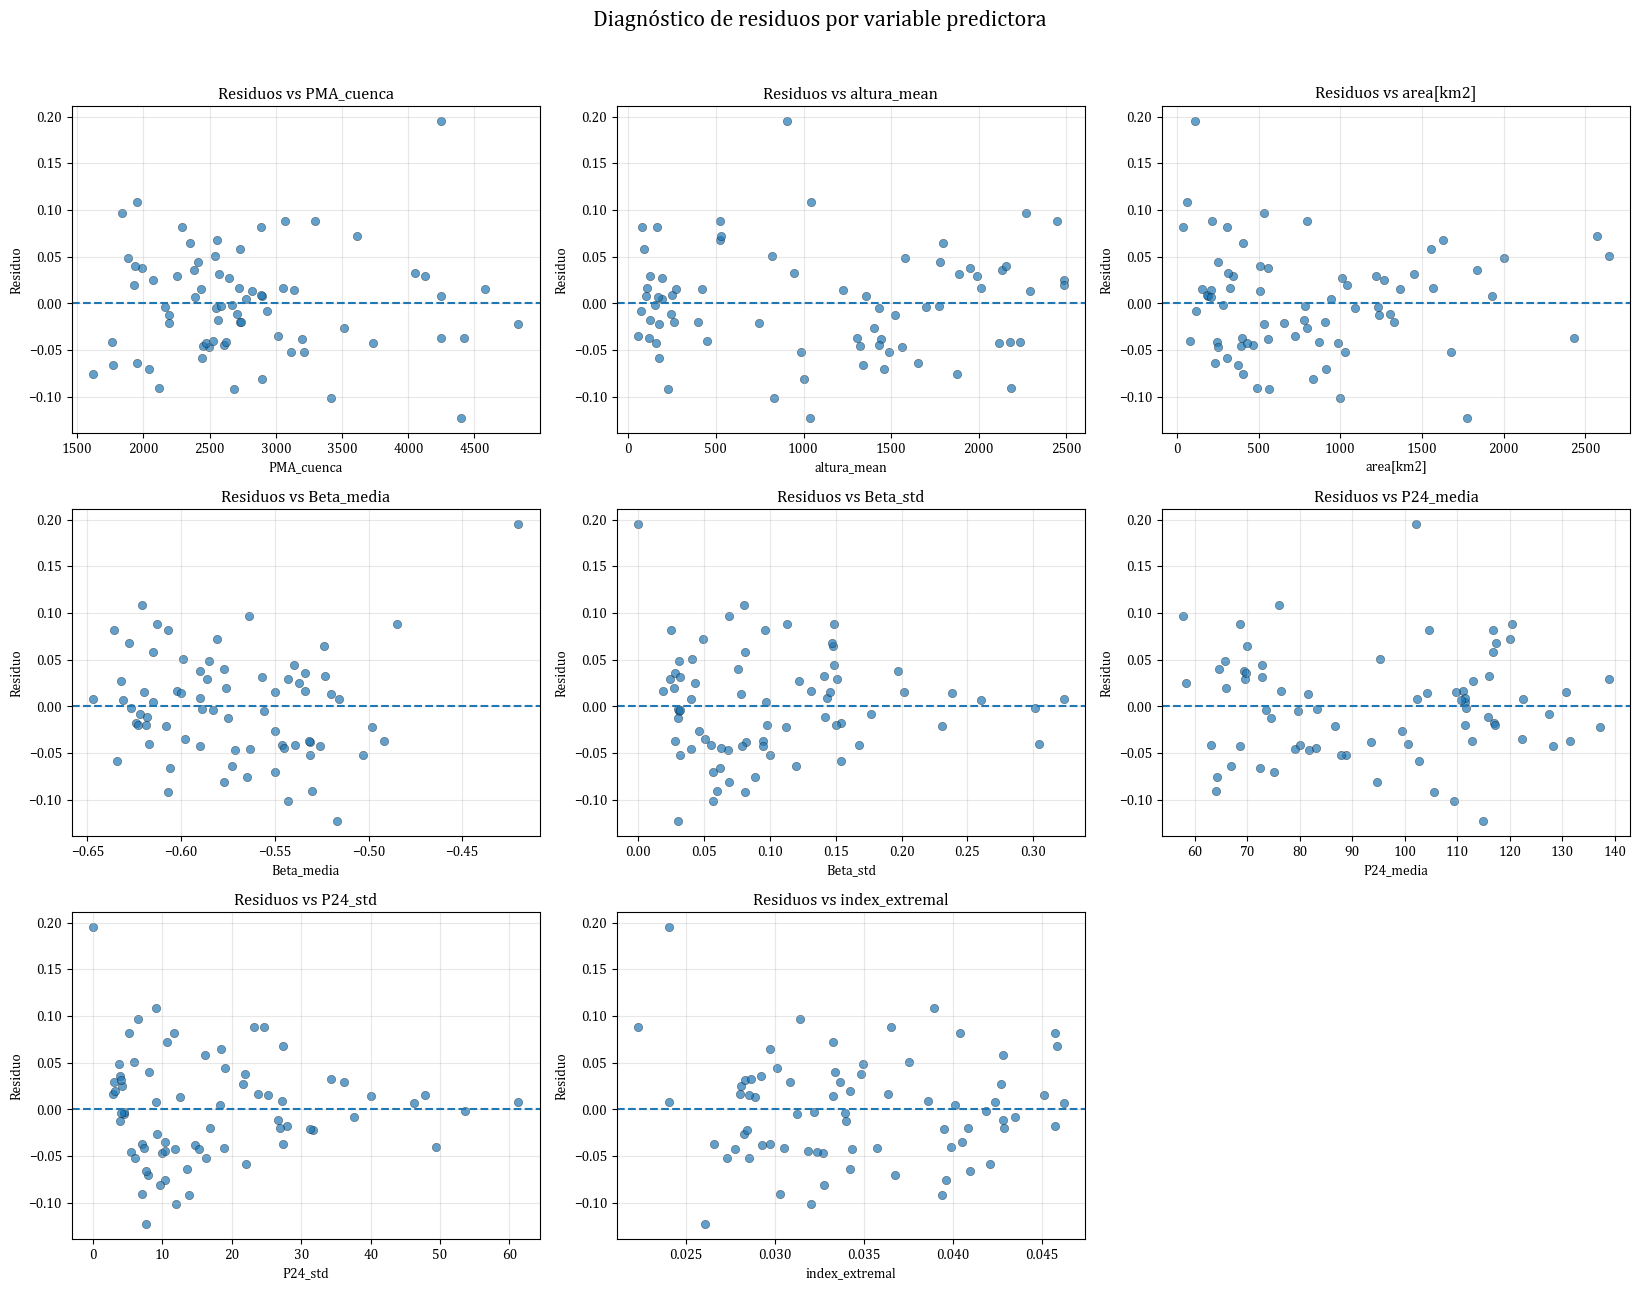

In [23]:
n_vars = len(predictoras)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 4.2 * n_rows)
)

axes = axes.flatten()

for i, var in enumerate(predictoras):
    ax = axes[i]

    ax.scatter(
        df_model[var],
        df_model["residuo"],
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3
    )

    ax.axhline(0, linestyle="--", linewidth=1.5)

    ax.set_xlabel(var)
    ax.set_ylabel("Residuo")
    ax.set_title(f"Residuos vs {var}")
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Diagnóstico de residuos por variable predictora", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'FRA predicho por GLM Gaussiano')

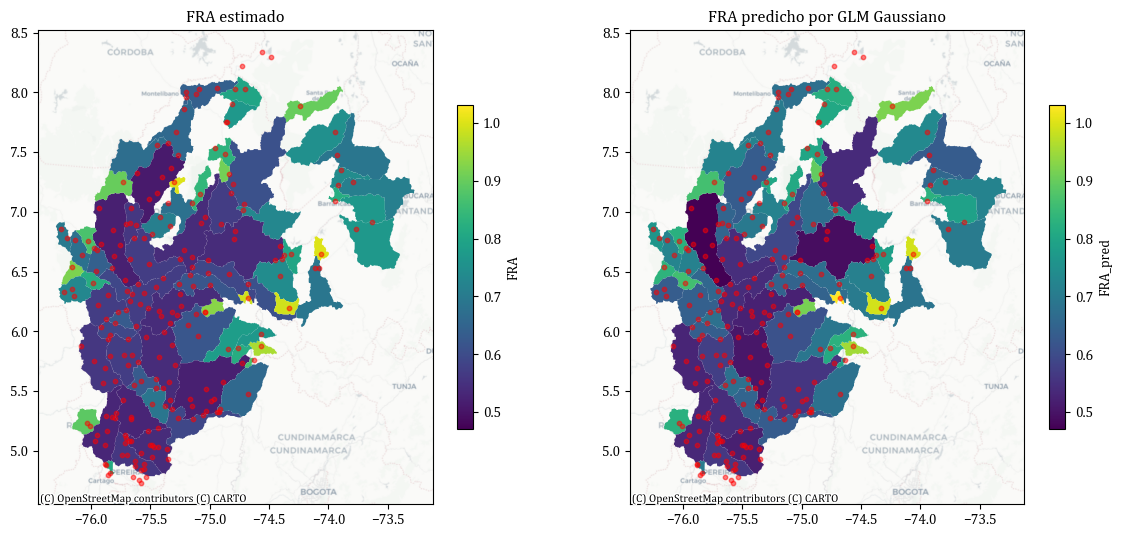

In [24]:
vmin = min(cuencas["FRA"].min(), cuencas["FRA_pred"].min())
vmax = max(cuencas["FRA"].max(), cuencas["FRA_pred"].max())
fig,ax=plt.subplots(1,2,figsize=(14,7))
cuencas.plot(ax=ax[0],column='FRA',legend=True,legend_kwds={'label': 'FRA','orientation':'vertical','shrink':0.6},vmin=vmin,vmax=vmax)
estaciones.plot(ax=ax[0],color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax[0],crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)

cuencas.plot(ax=ax[1],column='FRA_pred',legend=True,legend_kwds={'label': 'FRA_pred','orientation':'vertical','shrink':0.6},vmin=vmin,vmax=vmax)
estaciones.plot(ax=ax[1],color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax[1],crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)

ax[0].set_title("FRA estimado")
ax[1].set_title("FRA predicho por GLM Gaussiano")

### Se sacan las variables que no son estadisticamente significativas
**Conclusiones:** 
* El área presentó un coeficiente negativo con el FRA, resultado que se esperaba. A mayor área menor FRA.
* Beta presentó un coeficiente positivo, en donde Beta menos negativos, asociados a lluvias mas regulares. Presentan mayores valores de FRA
* Beta std presentó el coeficiente positivo de mayor magnitud, sugiriendo que la heterogeneidad espacial del régimen de escalamiento de la lluvia dentro de la cuenca tiene una influencia importante sobre el FRA estimado.
* P24_std se sacó porque no es estadísticamente significativo en este modelo

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Opcional si tienes Cambria instalada
plt.rcParams["font.family"] = "Cambria"

# -------------------- #
# Variable respuesta
# -------------------- #

var_y = "FRA"

# -------------------- #
# Variables predictoras
# -------------------- #

predictoras = [
    "area[km2]",
    "Beta_media",
    "Beta_std"
]

cols = [var_y] + predictoras

df_model = cuencas[cols].copy()

# Convertir a numérico
for c in cols:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

# Eliminar infinitos y nulos
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=cols).copy()

# -------------------- #
# Matriz X y vector y
# -------------------- #

X_raw = df_model[predictoras].copy()
y = df_model[var_y].copy()

# Escalar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convertir a DataFrame para conservar nombres
X_scaled = pd.DataFrame(
    X_scaled,
    columns=predictoras,
    index=df_model.index
)

# Agregar constante/intercepto
X = sm.add_constant(X_scaled)

# -------------------- #
# Modelo GLM Gaussiano
# -------------------- #

modelo_glm = sm.GLM(
    y,
    X,
    family=sm.families.Gaussian()
)

resultado_glm = modelo_glm.fit()

print(resultado_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    FRA   No. Observations:                   72
Model:                            GLM   Df Residuals:                       68
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                       0.0044702
Method:                          IRLS   Log-Likelihood:                 94.666
Date:                Tue, 14 Jul 2026   Deviance:                      0.30397
Time:                        01:00:33   Pearson chi2:                    0.304
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9674
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7078      0.008     89.826      0.0

In [33]:
# Predicciones
df_model["FRA_pred"] = resultado_glm.predict(X)

# Residuos
df_model["residuo"] = df_model["FRA"] - df_model["FRA_pred"]

# Residuo absoluto
df_model["residuo_abs"] = df_model["residuo"].abs()

# Copiar resultados a la capa original
cuencas["FRA_pred"] = np.nan
cuencas["residuo"] = np.nan
cuencas["residuo_abs"] = np.nan

cuencas.loc[df_model.index, "FRA_pred"] = df_model["FRA_pred"]
cuencas.loc[df_model.index, "residuo"] = df_model["residuo"]
cuencas.loc[df_model.index, "residuo_abs"] = df_model["residuo_abs"]
rmse = np.sqrt(mean_squared_error(df_model["FRA"], df_model["FRA_pred"]))
mae = mean_absolute_error(df_model["FRA"], df_model["FRA_pred"])
r2 = r2_score(df_model["FRA"], df_model["FRA_pred"])
# R2 ajustado
n = len(df_model)              # número de observaciones
p = len(predictoras)           # número de variables predictoras usadas en el modelo

r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)
print("R² ajustado:", r2_ajustado)
print("AIC:", resultado_glm.aic)
print("BIC:", resultado_glm.bic)

RMSE: 0.06497571242714631
MAE: 0.04629037996231506
R²: 0.7837596481514608
R² ajustado: 0.7742196326287312
AIC: -181.33166089723147
BIC: -290.5093233823019


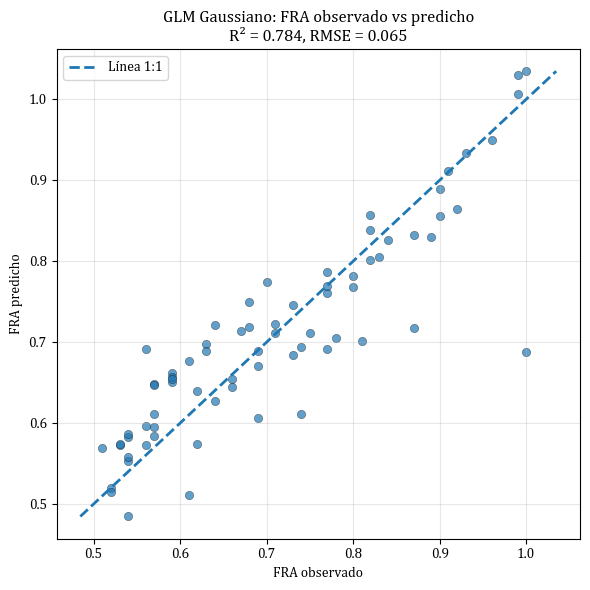

In [34]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df_model["FRA"],
    df_model["FRA_pred"],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

min_val = min(df_model["FRA"].min(), df_model["FRA_pred"].min())
max_val = max(df_model["FRA"].max(), df_model["FRA_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="Línea 1:1"
)

plt.xlabel("FRA observado")
plt.ylabel("FRA predicho")
plt.title(f"GLM Gaussiano: FRA observado vs predicho\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

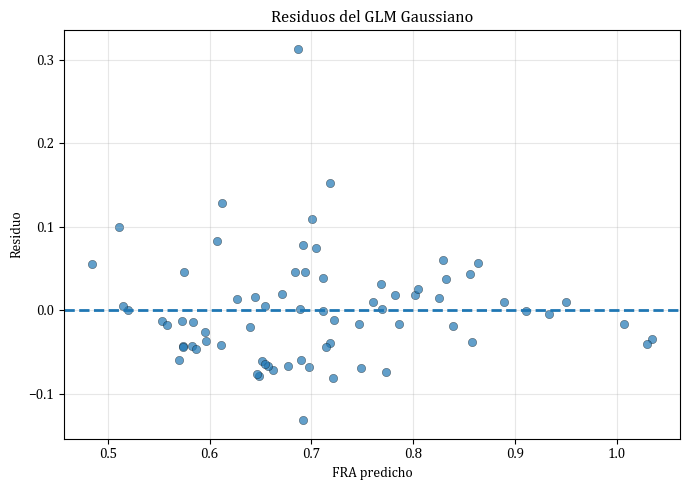

In [35]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_model["FRA_pred"],
    df_model["residuo"],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("FRA predicho")
plt.ylabel("Residuo")
plt.title("Residuos del GLM Gaussiano")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Área: Para el área no se observa tendencia alrededor de los residuos, sin embargo hay un punton con residual de 0.3. Lo que quiere decir que se predijo un valor mucho menor, esto en una cuenca pequeña. Sugiere que podrá funcionar mejor para cuencas de área grande
* Beta: No se observa ninguna tendencia, únicamente un punto cerca de -0.42. Podría ser el mismo outlier
* Beta-std: nuevamente hay un outlier. En rangos bajos de heterogeneidad espacial, no está capturando del todo bien el modelo

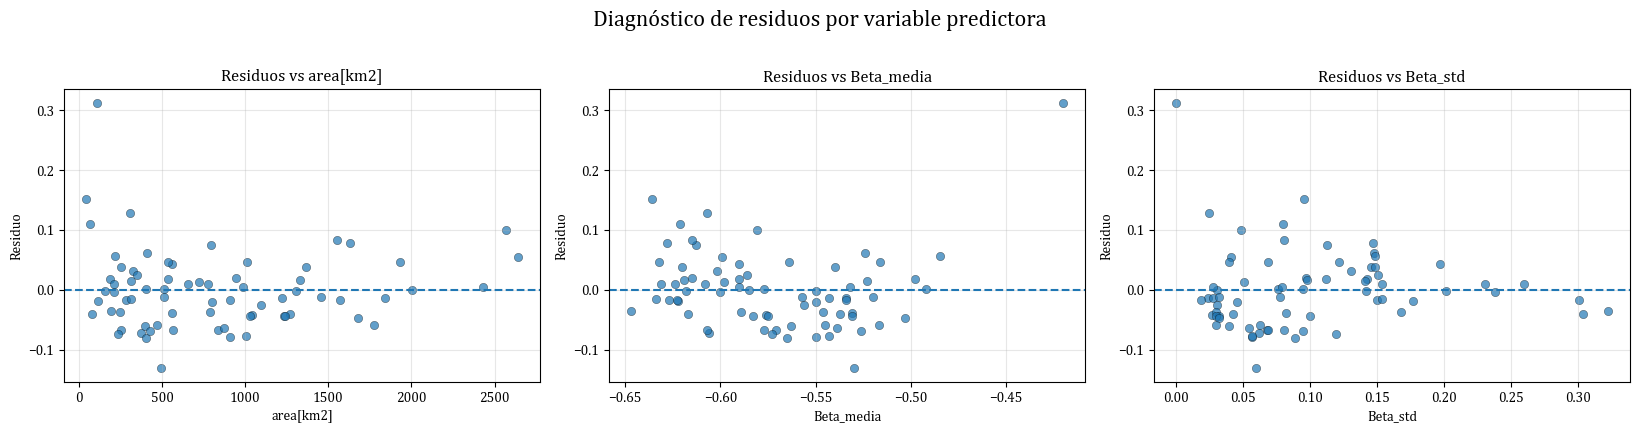

In [36]:
n_vars = len(predictoras)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 4.2 * n_rows)
)

axes = axes.flatten()

for i, var in enumerate(predictoras):
    ax = axes[i]

    ax.scatter(
        df_model[var],
        df_model["residuo"],
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3
    )

    ax.axhline(0, linestyle="--", linewidth=1.5)

    ax.set_xlabel(var)
    ax.set_ylabel("Residuo")
    ax.set_title(f"Residuos vs {var}")
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Diagnóstico de residuos por variable predictora", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'FRA predicho por GLM Gaussiano')

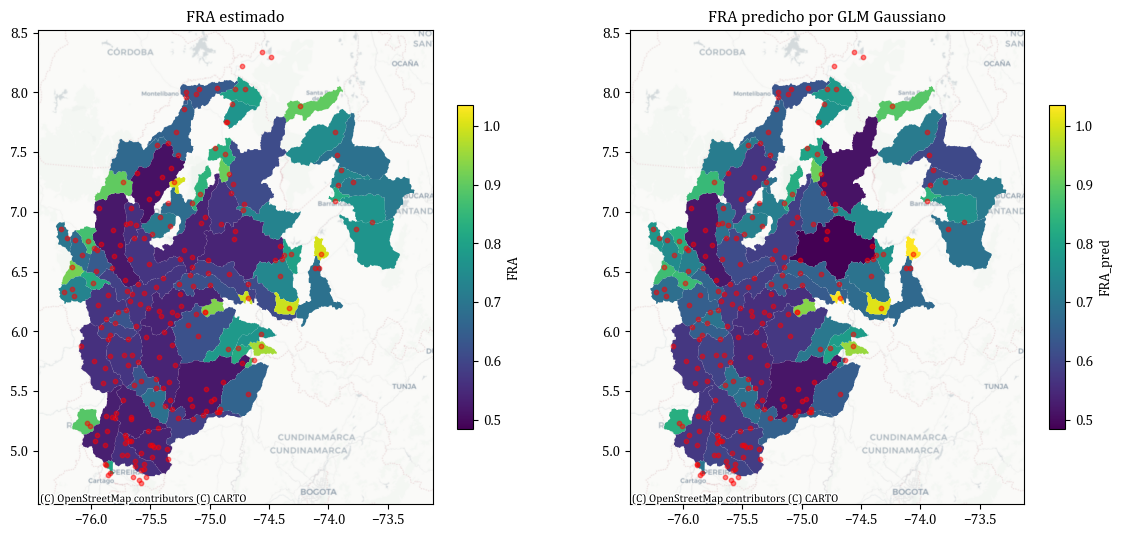

In [37]:
vmin = min(cuencas["FRA"].min(), cuencas["FRA_pred"].min())
vmax = max(cuencas["FRA"].max(), cuencas["FRA_pred"].max())
fig,ax=plt.subplots(1,2,figsize=(14,7))
cuencas.plot(ax=ax[0],column='FRA',legend=True,legend_kwds={'label': 'FRA','orientation':'vertical','shrink':0.6},vmin=vmin,vmax=vmax)
estaciones.plot(ax=ax[0],color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax[0],crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)

cuencas.plot(ax=ax[1],column='FRA_pred',legend=True,legend_kwds={'label': 'FRA_pred','orientation':'vertical','shrink':0.6},vmin=vmin,vmax=vmax)
estaciones.plot(ax=ax[1],color='red',markersize=10,alpha=0.5)
ctx.add_basemap(ax=ax[1],crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)

ax[0].set_title("FRA estimado")
ax[1].set_title("FRA predicho por GLM Gaussiano")

In [38]:
#cuencas.to_file(r"carto\cuencas_Gauss.gpkg")